# Reverse Split Strategy: Deep Dive & Optimization

In this notebook, we extend the backtest to explore the complete price trajectory of penny stocks undergoing reverse splits.
We will construct an **Event Study Curve** to visualize the average price action, and we will backtest various fixed and dynamic **holding periods** to find the absolute optimal time to cover the short.


In [1]:
import os
import sys
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Add src to path
current_dir = Path(os.getcwd())
sys.path.append(str(current_dir.parent / 'src'))

from split_strategy.database import get_collection, REVERSE_SPLITS_COLLECTION, EDGAR_COLLECTION
from bson.objectid import ObjectId

plt.style.use('ggplot')

# Load Data
reverse_coll = get_collection(REVERSE_SPLITS_COLLECTION)
edgar_coll = get_collection(EDGAR_COLLECTION)

edgar_filings = list(edgar_coll.find({"tier": {"$in": ["A", "B"]}}))
split_ids = set([str(f['reverse_splits_id']) for f in edgar_filings])
object_ids = [ObjectId(sid) for sid in split_ids]
splits = list(reverse_coll.find({"_id": {"$in": object_ids}}))

prices_path = current_dir.parent / "data" / "prices.pkl"
prices = pd.read_pickle(prices_path)

# Prepare Trading Events
split_events = []
for split in splits:
    split_id = str(split['_id'])
    filings = [f for f in edgar_filings if str(f['reverse_splits_id']) == split_id]
    if not filings: continue
    ticker = split.get('Symbol')
    if not ticker: continue
    df_f = pd.DataFrame(filings)
    df_f['filing_date_obj'] = pd.to_datetime(df_f['filing_date'], errors='coerce')
    earliest_filing = df_f.loc[df_f['filing_date_obj'].idxmin()]
    
    t_ann = earliest_filing['filing_date_obj']
    t_split = pd.to_datetime(split['Date'], errors='coerce')
    split_events.append({'ticker': ticker, 't_ann': t_ann, 't_split': t_split})

df_events = pd.DataFrame(split_events).dropna(subset=['t_ann', 't_split']).sort_values('t_ann')
print(f"Loaded {len(df_events)} valid split events with both Announcement and Split dates.")


Loaded 655 valid split events with both Announcement and Split dates.


## 1. Event Study: Average Price Path
We will align all stocks such that Day 0 is the event date. We normalize their prices to 1.0 (100%) on Day 0 and track the average percent change before and after.
*(Note: yfinance historical prices are already split-adjusted, meaning the actual reverse split ratio is accounted for and does not cause an artificial price spike on the chart).*


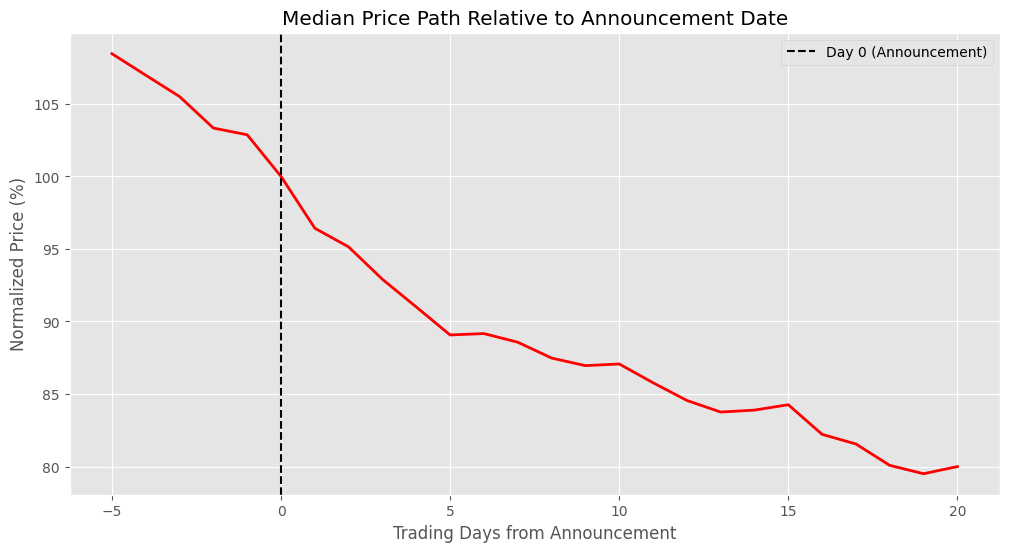

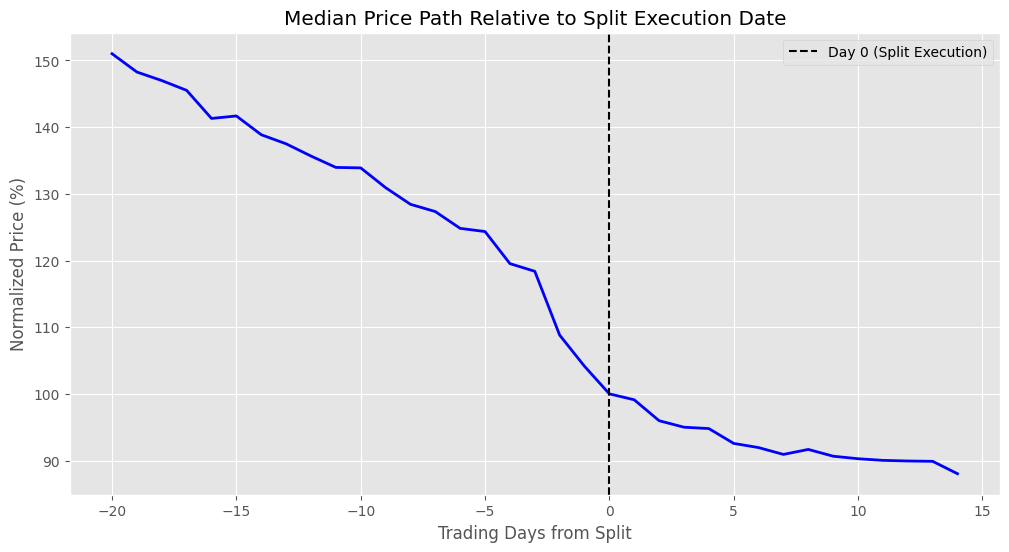

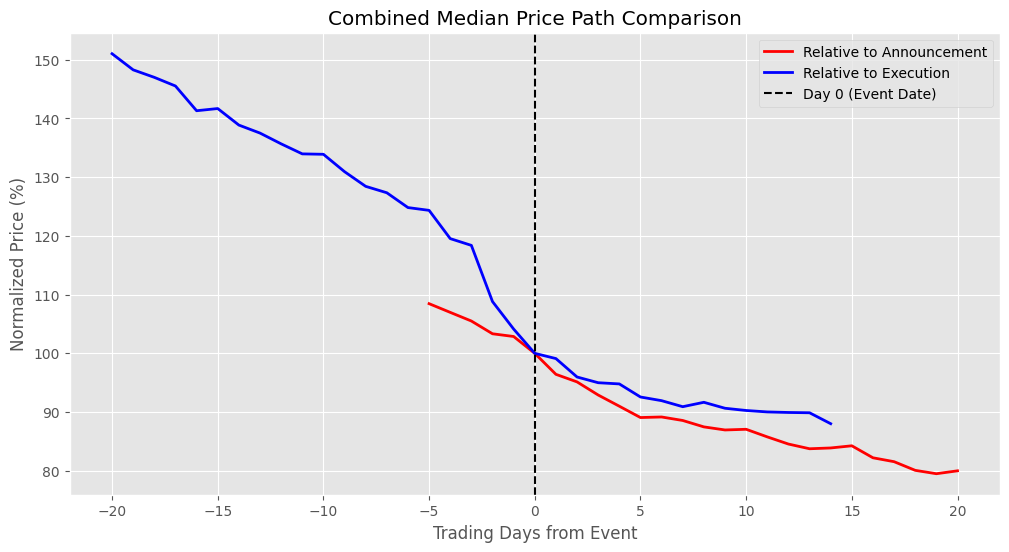

In [2]:
def get_event_window(ticker, event_date, before=14, after=14):
    if ticker not in prices.columns.levels[0]: return None
    t_data = prices[ticker]['Open'].dropna()
    if t_data.empty: return None
    post_event = t_data[t_data.index >= event_date]
    if post_event.empty: return None
    
    idx_0 = t_data.index.get_loc(post_event.index[0])
    start_idx = max(0, idx_0 - before)
    end_idx = min(len(t_data), idx_0 + after + 1)
    
    window_data = t_data.iloc[start_idx:end_idx]
    day0_price = t_data.iloc[idx_0]
    if day0_price == 0 or pd.isna(day0_price): return None
    
    normalized = window_data / day0_price
    rel_days = np.arange(start_idx - idx_0, end_idx - idx_0)
    return pd.Series(normalized.values, index=rel_days)

curves_ann = []
curves_split = []

for _, row in df_events.iterrows():
    s_ann = get_event_window(row['ticker'], row['t_ann'], before=5, after=20)
    if s_ann is not None: curves_ann.append(s_ann)
    s_split = get_event_window(row['ticker'], row['t_split'], before=20, after=14)
    if s_split is not None: curves_split.append(s_split)

df_ann = pd.DataFrame(curves_ann)
df_split = pd.DataFrame(curves_split)

# Calculate MEDIAN instead of MEAN to avoid skew from 500% short-squeeze outliers
median_ann = df_ann.median().sort_index() * 100
median_split = df_split.median().sort_index() * 100

# Plotting Announcement Event Study
plt.figure(figsize=(12, 6))
plt.plot(median_ann.index, median_ann.values, color='red', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', label='Day 0 (Announcement)')
plt.title('Median Price Path Relative to Announcement Date')
plt.xlabel('Trading Days from Announcement')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.show()

# Plotting Split Execution Event Study
plt.figure(figsize=(12, 6))
plt.plot(median_split.index, median_split.values, color='blue', linewidth=2)
plt.axvline(x=0, color='black', linestyle='--', label='Day 0 (Split Execution)')
plt.title('Median Price Path Relative to Split Execution Date')
plt.xlabel('Trading Days from Split')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.show()

# Combined Graph
plt.figure(figsize=(12, 6))
plt.plot(median_ann.index, median_ann.values, color='red', linewidth=2, label='Relative to Announcement')
plt.plot(median_split.index, median_split.values, color='blue', linewidth=2, label='Relative to Execution')
plt.axvline(x=0, color='black', linestyle='--', label='Day 0 (Event Date)')
plt.title('Combined Median Price Path Comparison')
plt.xlabel('Trading Days from Event')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.show()


## 2. The Ultimate Strategy Grid Search
To find the absolute mathematically optimal strategy, we will run a massive multi-variable grid search covering thousands of permutations. We are utilizing the "Stepped Sizing" method (recalculating a 5% bet size every 30 days) to allow for safe exponential compounding.

**Variables Tested:**
1. **Hold Rule**: Testing fixed hold days (`1`, `2`, `5`, `10`, `14`) and dynamic event holds (`day_before_split`, `5_days_after_split`, etc.).
2. **Stop Loss**: Testing `15%`, `20%`, `25%`, `30%`, `35%`, `40%`, and `No Stop Loss`.
3. **Take Profit**: Testing `20%`, `40%`, `60%`, `80%`, and `No Take Profit`.
4. **Gap-Up Filter**: Testing skipping trades if the stock gapped up `>10%`, `>30%`, or `No Filter`.
5. **Split Ratio Buckets**: Testing `<10`, `10-50`, `>50`, or `All Ratios`.


In [3]:
# Extract Ratios
ticker_to_ratio = {}
for split in splits:
    t = split.get('Symbol')
    r_str = split.get('Split Ratio')
    if t and r_str and ':' in r_str:
        try: ticker_to_ratio[t] = float(r_str.split(':')[1].strip())
        except: pass
df_events['ratio'] = df_events['ticker'].map(ticker_to_ratio)

def backtest_mega(hold_rule, stop_loss=0.20, take_profit=float('inf'), max_gap_up=float('inf'), min_ratio=0, max_ratio=float('inf')):
    slippage_and_fees = 0.015
    portfolio_value = 10000.0
    last_rebalance_date = None
    trades = []
    
    for idx, row in df_events.iterrows():
        ticker = row['ticker']
        ratio = row['ratio']
        if pd.isna(ratio) or ratio < min_ratio or ratio > max_ratio: continue
            
        if ticker not in prices.columns.levels[0]: continue
        ticker_data = prices[ticker]
        
        future_data = ticker_data[ticker_data.index >= row['t_ann']]
        if future_data.empty: continue
        
        entry_price = future_data.iloc[0]['Open']
        entry_date = future_data.index[0]
        if pd.isna(entry_price) or entry_price <= 0: continue
            
        # Gap-Up Filter
        prev_data = ticker_data[ticker_data.index < entry_date]
        if not prev_data.empty:
            prev_close = prev_data.iloc[-1]['Close']
            if prev_close > 0:
                gap_up = (entry_price - prev_close) / prev_close
                if gap_up > max_gap_up:
                    continue # Skip trade!
        
        # Determine maximum holding index based on rule
        if isinstance(hold_rule, int):
            max_hold_days = hold_rule
            holding_data = future_data.iloc[1:max_hold_days+1]
        elif hold_rule == 'day_before_split':
            holding_data = future_data[(future_data.index > entry_date) & (future_data.index < row['t_split'])]
        elif hold_rule == 'day_of_split':
            holding_data = future_data[(future_data.index > entry_date) & (future_data.index <= row['t_split'])]
        elif hold_rule == 'day_after_split':
            holding_data = future_data[(future_data.index > entry_date)]
            post_split = holding_data[holding_data.index > row['t_split']]
            if not post_split.empty: holding_data = holding_data.loc[:post_split.index[0]]
            else: holding_data = future_data[(future_data.index > entry_date) & (future_data.index <= row['t_split'])]
        elif hold_rule == '5_days_after_split':
            holding_data = future_data[(future_data.index > entry_date)]
            post_split = holding_data[holding_data.index >= row['t_split']]
            if len(post_split) > 5: holding_data = holding_data.loc[:post_split.index[5]]
        elif hold_rule == '10_days_after_split':
            holding_data = future_data[(future_data.index > entry_date)]
            post_split = holding_data[holding_data.index >= row['t_split']]
            if len(post_split) > 10: holding_data = holding_data.loc[:post_split.index[10]]
        elif hold_rule == '14_days_after_split':
            holding_data = future_data[(future_data.index > entry_date)]
            post_split = holding_data[holding_data.index >= row['t_split']]
            if len(post_split) > 14: holding_data = holding_data.loc[:post_split.index[14]]
        else:
            continue
            
        if last_rebalance_date is None: last_rebalance_date = entry_date
        if entry_date >= last_rebalance_date + pd.Timedelta(days=30):
            last_rebalance_date = entry_date
        current_bet_size = portfolio_value * 0.05
        
        stop_loss_price = entry_price * (1 + stop_loss)
        take_profit_price = entry_price * (1 - take_profit)
        
        exit_price = None
        for h_idx, h_row in holding_data.iterrows():
            if h_row['High'] >= stop_loss_price:
                exit_price = stop_loss_price
                break
            if h_row['Low'] <= take_profit_price:
                exit_price = take_profit_price
                break
                
        if exit_price is None and not holding_data.empty:
            exit_price = holding_data.iloc[-1]['Open']
            
        if exit_price is None: continue
        
        raw_pct_return = (entry_price - exit_price) / entry_price
        net_pct_return = raw_pct_return - slippage_and_fees
        profit_dollars = current_bet_size * net_pct_return
        
        portfolio_value += profit_dollars
        trades.append(profit_dollars)
        
        # Bankruptcy check!
        if portfolio_value <= 0:
            portfolio_value = 0
            break
            
    df = pd.Series(trades)
    return {
        'hold_rule': hold_rule,
        'stop_loss': stop_loss,
        'take_profit': take_profit,
        'max_gap_up': max_gap_up,
        'ratio_range': f"{min_ratio} to {max_ratio}",
        'total_trades': len(df),
        'win_rate': (df > 0).mean() * 100 if len(df) > 0 else 0,
        'final_portfolio_value': portfolio_value,
        'total_return_pct': ((portfolio_value - 10000) / 10000) * 100
    }

params = []
hold_rules = [1, 2, 5, 10, 14, 'day_before_split', 'day_of_split', 'day_after_split', '5_days_after_split', '10_days_after_split', '14_days_after_split']
stop_losses = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, float('inf')]
take_profits = [0.20, 0.40, 0.60, 0.80, float('inf')]
gap_ups = [0.10, 0.30, float('inf')]
ratios = [(0, float('inf')), (0, 10), (10, 50), (50, float('inf'))]

for hr in hold_rules:
    for sl in stop_losses:
        for tp in take_profits:
            for gap in gap_ups:
                for r_min, r_max in ratios:
                    params.append({'hold_rule': hr, 'stop_loss': sl, 'take_profit': tp, 'max_gap_up': gap, 'min_ratio': r_min, 'max_ratio': r_max})

print(f"Running mega optimization grid search with {len(params)} permutations... This might take around 15 minutes.")
opt_results = [backtest_mega(**p) for p in params]
df_opt = pd.DataFrame(opt_results).sort_values('total_return_pct', ascending=False)
df_opt.head(20)


Running mega optimization grid search with 4620 permutations... This might take ~1 minute.


,hold_rule,stop_loss,take_profit,max_gap_up,ratio_range,total_trades,win_rate,final_portfolio_value,total_return_pct
3716,5_days_after_split,0.40,inf,inf,0 to inf,635,59.055118,506119.675379,4961.196754
3712,5_days_after_split,0.40,inf,0.3,0 to inf,634,58.990536,504645.441880,4946.454419
3708,5_days_after_split,0.40,inf,0.1,0 to inf,625,58.720000,458745.542078,4487.455421
4136,10_days_after_split,0.40,inf,inf,0 to inf,635,57.165354,424510.454946,4145.104549
3704,5_days_after_split,0.40,0.8,inf,0 to inf,635,59.842520,422429.337179,4124.293372
3700,5_days_after_split,0.40,0.8,0.3,0 to inf,634,59.779180,421198.878238,4111.988782
4132,10_days_after_split,0.40,inf,0.3,0 to inf,634,57.097792,417955.423496,4079.554235
2513,day_before_split,inf,inf,0.3,0 to 10,237,80.168776,389804.319657,3798.043197
2517,day_before_split,inf,inf,inf,0 to 10,237,80.168776,389804.319657,3798.043197
3696,5_days_after_split,0.40,0.8,0.1,0 to inf,625,59.520000,383300.897313,3733.008973
